# ECE 447 Project B: Anomaly Detection

---

### Team Members
* **Member 1:** Basma Ebeid
* **Member 2:** Sara Bader
* **Member 3:** Chidinma Obi-Okoye
* **Date:** April 20 2026

---

**AI Use Statement**

Tools used: ChatGPT

What we used it for: ChatGPT was used to assist with improving code organization, debugging errors, and refining explanations throughout the notebook. It also helped structure sections of the report, including method descriptions, evaluation setup, and markdown clarity.

What we verified/changed: All code was reviewed, tested, and modified as needed. We verified all model outputs, ensured correctness of evaluation metrics (precision, recall, F1, FPR), and confirmed that threshold selection and model comparisons were accurate and consistent with the analysis.

What is ours: All modeling decisions, including method selection (statistical, kNN, Isolation Forest), parameter tuning, threshold optimization, evaluation results, interpretations, and final conclusions are our own.

---

## 1. Problem Framing
This project is framed as a **Semi-Supervised Anomaly Detection** problem. We establish a baseline of "normal" transaction behavior and identify fraud as significant deviations from this distribution. Ground-truth labels are reserved for threshold optimization and final validation.

---

## Project Overview
This notebook evaluates and compares three distinct algorithmic approaches for detecting fraudulent credit card transactions. Given the extreme class imbalance, we focus on identifying anomalies through:

1.  **Statistical Scoring:** Robust Z-scoring using Median and MAD.
2.  **kNN (Distance-based):** Local density estimation using the $k^{th}$ nearest neighbor.
3.  **Isolation Forest:** Ensemble-based isolation via random partitioning.

---

## Notebook Structure
* **Data Pipeline:** Cleaning, scaling, and stratified artifact generation.
* **Model Development:** Implementation, hyperparameter tuning, and MLflow tracking.
* **Performance Evaluation:** Comprehensive analysis using P/R/F1, ROC/PR curves, and FPR analysis.
* **Interpretability:** t-SNE visualization, score distributions, and feature-shift explanation tables.

> **Note:** Final performance is reported on a held-out **Test Set** using thresholds optimized on **Validation** data to ensure realistic, unbiased performance estimates.

---

## 2. Notebook Setup and Helper Functions

This section loads the dataset, prepares the train/validation/test splits, and defines reusable helper functions used throughout the notebook.

In [23]:
from __future__ import annotations
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [24]:
# Constants
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
THRESHOLD_QUANTILE_GRID = np.linspace(0.90, 0.9999, 50)
DATA_PATH = "../data/creditcard.csv"

# Directory Resolution
BASE_DIR = Path.cwd().resolve()
PROJECT_ROOT = BASE_DIR
for candidate in (BASE_DIR, BASE_DIR.parent, BASE_DIR.parent.parent):
    if (candidate / "artifacts").is_dir():
        PROJECT_ROOT = candidate
        break


print(f"Resolved project root: {PROJECT_ROOT}")

Resolved project root: C:\Users\basma\OneDrive\Documents\ECE 447\Project


In [25]:

def _split_from_dataframe(df: pd.DataFrame):
    """Shared train/val/test split + scaling (same logic as project pipeline)."""
    df = df.drop_duplicates()

    normal = df[df["Class"] == 0].copy()
    fraud = df[df["Class"] == 1].copy()

    X_norm = normal.drop(columns=["Class"])
    y_norm = normal["Class"]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_norm, y_norm, test_size=0.40, random_state=RANDOM_STATE
    )

    X_val_norm, X_test_norm, y_val_norm, y_test_norm = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
    )

    X_fraud = fraud.drop(columns=["Class"])
    y_fraud = fraud["Class"]

    X_val_fraud, X_test_fraud, y_val_fraud, y_test_fraud = train_test_split(
        X_fraud, y_fraud, test_size=0.50, random_state=RANDOM_STATE
    )

    X_val = pd.concat([X_val_norm, X_val_fraud])
    y_val = pd.concat([y_val_norm, y_val_fraud])
    X_test = pd.concat([X_test_norm, X_test_fraud])
    y_test = pd.concat([y_test_norm, y_test_fraud])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return (
        X_train_scaled,
        X_val_scaled,
        X_test_scaled,
        y_train.values,
        y_val.values,
        y_test.values,
        scaler,
    )


def resolve_creditcard_csv(project_root: Union[str, Path]) -> Path:
    """
    Locate creditcard.csv. Search order:
    1. Environment variable CREDITCARD_CSV
    2. <project_root>/data/creditcard.csv
    3. <project_root>/creditcard.csv
    4. kagglehub.dataset_download('mlg-ulb/creditcardfraud')
    """
    root = Path(project_root).resolve()

    env = os.environ.get("CREDITCARD_CSV", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if p.is_file():
            return p

    for rel in ("data/creditcard.csv", "creditcard.csv"):
        p = (root / rel).resolve()
        if p.is_file():
            return p

    try:
        import kagglehub

        hub_dir = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
        for f in hub_dir.rglob("creditcard.csv"):
            if f.is_file():
                return f.resolve()
    except Exception:
        pass

    data_dir = root / "data"
    data_dir.mkdir(parents=True, exist_ok=True)
    raise FileNotFoundError(
        "Could not find creditcard.csv.\n\n"
        "  - Place the Kaggle file at: "
        f"{data_dir / 'creditcard.csv'}\n"
        "  - Or set CREDITCARD_CSV to its full path\n"
        "  - Or install kagglehub + Kaggle API credentials for auto-download\n"
    )


def load_and_split(data_path=DATA_PATH):
    df = pd.read_csv(data_path)
    return _split_from_dataframe(df)


def load_splits(artifact_path: Union[str, Path] = "../artifacts/") -> Tuple[np.ndarray, ...]:
    base = Path(artifact_path)
    if not base.is_dir():
        raise FileNotFoundError(f"Artifact directory not found: {base}")
    X_train = np.load(base / "X_train.npy")
    X_val = np.load(base / "X_val.npy")
    X_test = np.load(base / "X_test.npy")
    y_train = np.load(base / "y_train.npy")
    y_val = np.load(base / "y_val.npy")
    y_test = np.load(base / "y_test.npy")
    return X_train, X_val, X_test, y_train, y_val, y_test


def load_credit_card_splits(
    project_root: Union[str, Path],
    *,
    verbose: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    root = Path(project_root).resolve()
    art = root / "artifacts"
    if (art / "X_train.npy").is_file():
        if verbose:
            print(f"Loaded splits from {art} (saved .npy).")
        return load_splits(art)

    csv_local = root / "data" / "creditcard.csv"
    if csv_local.is_file():
        if verbose:
            print(f"Loaded from {csv_local} via load_and_split.")
        X_train, X_val, X_test, y_train, y_val, y_test, _ = load_and_split(str(csv_local))
        return X_train, X_val, X_test, y_train, y_val, y_test

    csv_path = resolve_creditcard_csv(root)
    if verbose:
        print(f"Using creditcard.csv: {csv_path}")
    X_train, X_val, X_test, y_train, y_val, y_test, _ = load_and_split(str(csv_path))
    return X_train, X_val, X_test, y_train, y_val, y_test

def metrics_at_threshold(y_true: np.ndarray, pred: np.ndarray) -> Dict[str, float]:
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )
    tn = int(np.sum((pred == 0) & (y_true == 0)))
    fp = int(np.sum((pred == 1) & (y_true == 0)))
    fn = int(np.sum((pred == 0) & (y_true == 1)))
    tp = int(np.sum((pred == 1) & (y_true == 1)))
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return {
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "fpr": float(fpr),
        "tp": float(tp),
        "fp": float(fp),
        "tn": float(tn),
        "fn": float(fn),
    }




## 3. Data Management Strategy
To ensure reproducibility and efficiency, we implemented a **two-tier loading strategy**:
1. **Artifact Recovery:** The system first attempts to load pre-processed `.npy` splits from the `/artifacts` directory. This ensures that every team member (and the grader) uses the exact same shuffled data distribution across different sessions.
2. **Cold Start:** If artifacts are missing, the pipeline performs a fresh load of `creditcard.csv`, applies stratified splitting, and persists the new artifacts for future use.

In [26]:
X_train, X_val, X_test, y_train, y_val, y_test = load_credit_card_splits(PROJECT_ROOT)

FEATURE_NAMES = [f"V{i}" for i in range(1, 29)] + ["Time", "Amount"]
print("Train / val / test:", X_train.shape, X_val.shape, X_test.shape)
print("Fraud rate val:", f"{y_val.mean():.4%}", "| test:", f"{y_test.mean():.4%}")


Using creditcard.csv: C:\Users\basma\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv
Train / val / test: (169951, 30) (56887, 30) (56888, 30)
Fraud rate val: 0.4149% | test: 0.4166%


## 4. Statistical Anomaly Detector

**Methodology**
This method utilizes **Robust Z-Scores** based on the **Median** and **Median Absolute Deviation (MAD)** calculated from the training data. This approach is more resilient to outliers than standard mean-based Z-scores.

**Scoring & Selection**
* Each transaction is assigned an anomaly score equal to the **maximum absolute z-score** across all features.
* The decision threshold is optimized on the **validation set** by maximizing the **F1-score** across a range of score quantiles. 

This ensures that we select a threshold that balances high fraud detection (Recall) with a manageable number of false alarms (Precision).

In [27]:
def fit_robust_mad_params(X_ref: np.ndarray):
    med = np.median(X_ref, axis=0)
    mad = np.median(np.abs(X_ref - med), axis=0)
    mad = np.where(mad < 1e-12, 1e-12, mad)
    return med, mad


def statistical_anomaly_scores(X: np.ndarray, med: np.ndarray, mad: np.ndarray) -> np.ndarray:
    z = 0.6745 * (X - med) / mad
    return np.max(np.abs(z), axis=1)


med, mad = fit_robust_mad_params(X_train)
scores_stat_val = statistical_anomaly_scores(X_val, med, mad)
scores_stat_test = statistical_anomaly_scores(X_test, med, mad)


def pick_threshold_max_f1(scores: np.ndarray, y_true: np.ndarray, quantiles=None):
    if quantiles is None:
        quantiles = THRESHOLD_QUANTILE_GRID
    best_f1, best_thr = -1.0, float(np.quantile(scores, 0.99))
    for q in quantiles:
        thr = float(np.quantile(scores, q))
        pred = (scores >= thr).astype(int)
        m = metrics_at_threshold(y_true, pred)
        if m["f1"] > best_f1:
            best_f1, best_thr = m["f1"], thr
    return best_thr


THRESHOLD_STAT = pick_threshold_max_f1(scores_stat_val, y_val)
pred_stat_val = (scores_stat_val >= THRESHOLD_STAT).astype(int)
pred_stat_test = (scores_stat_test >= THRESHOLD_STAT).astype(int)

print("Statistical - val:", metrics_at_threshold(y_val, pred_stat_val))
print("Statistical - test:", metrics_at_threshold(y_test, pred_stat_test))
print("Threshold (stat):", THRESHOLD_STAT)


Statistical - val: {'precision': 0.04536771728748806, 'recall': 0.4025423728813559, 'f1': 0.0815450643776824, 'fpr': 0.035286226191947184, 'tp': 95.0, 'fp': 1999.0, 'tn': 54652.0, 'fn': 141.0}
Statistical - test: {'precision': 0.033070088845014806, 'recall': 0.28270042194092826, 'f1': 0.059213433495360145, 'fpr': 0.03458014862932693, 'tp': 67.0, 'fp': 1959.0, 'tn': 54692.0, 'fn': 170.0}
Threshold (stat): 19.295547318262525


This statistical method is simple and interpretable, since large deviations in any feature increase the anomaly score. However, it may miss more complex patterns that involve relationships between multiple features.

## 5. Distance-Based Detector (kNN)

**Methodology**
The **k-Nearest Neighbors (kNN)** method identifies anomalies based on spatial distance. For each transaction, we define the anomaly score as the distance to its **$k^{th}$ nearest neighbor**. Transactions located in sparsely populated regions of the feature space result in larger distances and, consequently, higher anomaly scores.

**Parameter Selection**
The number of neighbors ($k$) was tuned using **MLflow**, evaluating a range of values ($k \in \{5, 10, 15, 20, 25, 30\}$). Our analysis showed:
* **Recall Trends:** As $k$ increased, the model's recall improved, allowing it to capture more fraudulent transactions.
* **Trade-offs:** Very large values of $k$ risk "smoothing out" local anomalies, potentially reducing sensitivity to subtle fraud patterns.

**Selection:** The optimal performance was achieved at **$k = 25$**, which yielded the highest **F1-score** and maintained a low false-positive rate. This configuration was selected for the final model.

In [28]:

def knn_kth_distance_scores(X: np.ndarray, nn: NearestNeighbors) -> np.ndarray:
    dists, _ = nn.kneighbors(X)
    return dists[:, -1]

K_NEIGHBORS_FINAL = 25

knn = NearestNeighbors(n_neighbors=K_NEIGHBORS_FINAL, metric="euclidean")
knn.fit(X_train)

scores_knn_val = knn_kth_distance_scores(X_val, knn)
scores_knn_test = knn_kth_distance_scores(X_test, knn)

THRESHOLD_KNN = pick_threshold_max_f1(scores_knn_val, y_val)

pred_knn_val = (scores_knn_val >= THRESHOLD_KNN).astype(int)
pred_knn_test = (scores_knn_test >= THRESHOLD_KNN).astype(int)

knn_val_metrics = metrics_at_threshold(y_val, pred_knn_val)
knn_test_metrics = metrics_at_threshold(y_test, pred_knn_test)

print("kNN (k=25) - Validation:", {k: knn_val_metrics[k] for k in ("precision", "recall", "f1", "fpr")})
print("kNN (k=25) - Test:", {k: knn_test_metrics[k] for k in ("precision", "recall", "f1", "fpr")})
print("Threshold:", THRESHOLD_KNN)

kNN (k=25) - Validation: {'precision': 0.4717514124293785, 'recall': 0.7076271186440678, 'f1': 0.5661016949152542, 'fpr': 0.0033009126052496868}
kNN (k=25) - Test: {'precision': 0.49025069637883006, 'recall': 0.7426160337552743, 'f1': 0.5906040268456376, 'fpr': 0.0032303048489876612}
Threshold: 10.930550886732988


This method is more flexible than the statistical baseline because it looks at local distance patterns instead of only per-feature deviations. However, its performance can depend on the choice of \(k\) and the distance metric.

## 6. Final Isolation Forest Model

**Methodology**
The **Isolation Forest** is an ensemble-based method that isolates anomalies by randomly partitioning features. Unlike traditional models that build a profile of "normal" behavior, this approach assumes anomalies are "few and different," making them easier to isolate with fewer splits in a decision tree.

**Model Tuning & Final Selection**
We used **MLflow** to conduct a hyperparameter sweep, specifically analyzing the impact of tree count, feature subsampling, and contamination levels.

#### **Key Observations**
* **Tree Count (`n_estimators`):** Model stability improved with more trees, reaching diminishing returns at **400 estimators**. Increasing the count to 500 provided no significant performance gain.
* **Feature Diversity (`max_features`):** The most significant improvement occurred when reducing `max_features` to **0.6**. By training each tree on a random subset of 60% of the features, we increased the forest's diversity and improved the F1-score.
* **Contamination:** Adjusting this parameter had minimal impact on final performance. This confirms that our external **threshold optimization** is the primary driver for controlling predictions, rather than the model's internal contamination setting.



#### **Final Configuration**
The final selected configuration is:
* **n_estimators:** 400
* **max_features:** 0.6
* **contamination:** 0.001

This setup provided the best balance of metrics, achieving a **Test F1-score of 0.362**. This configuration was selected because it captures fraudulent patterns effectively while maintaining a low false-positive rate, crucial for minimizing operational overhead.

In [29]:
def anomaly_scores_isolation_forest(model: IsolationForest, X: np.ndarray) -> np.ndarray:
    """Higher score = more anomalous."""
    return -model.decision_function(X)

@dataclass
class DetectorResult:
    anomaly_score: np.ndarray
    pred_label: np.ndarray
    threshold: float
    method: str = "isolation_forest"


def fit_isolation_forest(
    X_train: np.ndarray,
    *,
    n_estimators: int = 200,
    max_samples: Union[float, str] = "auto",
    max_features: float = 1.0,
    contamination: float = 0.001,
    random_state: int = 42,
) -> IsolationForest:
    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(X_train)
    return model


def sweep_thresholds_val(
    model: IsolationForest,
    X_val: np.ndarray,
    y_val: np.ndarray,
    quantile_grid: Optional[np.ndarray] = None,
) -> Tuple[float, pd.DataFrame]:
    """Pick threshold on validation by maximizing F1 over score quantiles."""
    if quantile_grid is None:
        quantile_grid = THRESHOLD_QUANTILE_GRID
    s = anomaly_scores_isolation_forest(model, X_val)
    rows = []
    best_f1 = -1.0
    best_thr = float(np.quantile(s, 0.99))
    for q in quantile_grid:
        thr = float(np.quantile(s, q))
        pred = (s >= thr).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            y_val, pred, average="binary", zero_division=0
        )
        tn = int(np.sum((pred == 0) & (y_val == 0)))
        fp = int(np.sum((pred == 1) & (y_val == 0)))
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        rows.append(
            {
                "quantile": q,
                "threshold": thr,
                "precision": p,
                "recall": r,
                "f1": f1,
                "fpr": fpr,
            }
        )
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, pd.DataFrame(rows)


def predict_with_threshold(
    model: IsolationForest, X: np.ndarray, threshold: float
) -> DetectorResult:
    scores = anomaly_scores_isolation_forest(model, X)
    pred = (scores >= threshold).astype(int)
    return DetectorResult(
        anomaly_score=scores, pred_label=pred, threshold=float(threshold)
    )


In [30]:
FINAL_IF_PARAMS = {
    "n_estimators": 400,
    "max_samples": "auto",
    "max_features": 0.6,
    "contamination": 0.001,
    "random_state": RANDOM_STATE,
}

if_model = fit_isolation_forest(X_train, **FINAL_IF_PARAMS)
THRESHOLD_IF, _ = sweep_thresholds_val(if_model, X_val, y_val)

val_result = predict_with_threshold(if_model, X_val, THRESHOLD_IF)
test_result = predict_with_threshold(if_model, X_test, THRESHOLD_IF)

if_val_metrics = metrics_at_threshold(y_val, val_result.pred_label)
if_test_metrics = metrics_at_threshold(y_test, test_result.pred_label)

print("Final Isolation Forest - val:", if_val_metrics)
print("Final Isolation Forest - test:", if_test_metrics)
print("Selected threshold:", THRESHOLD_IF)

Final Isolation Forest - val: {'precision': 0.3220338983050847, 'recall': 0.4830508474576271, 'f1': 0.3864406779661017, 'fpr': 0.004236465375721523, 'tp': 114.0, 'fp': 240.0, 'tn': 56411.0, 'fn': 122.0}
Final Isolation Forest - test: {'precision': 0.30791788856304986, 'recall': 0.4430379746835443, 'f1': 0.3633217993079585, 'fpr': 0.004165857619459498, 'tp': 105.0, 'fp': 236.0, 'tn': 56415.0, 'fn': 132.0}
Selected threshold: -0.05741706442720936


## 7. Final Evaluation & Model Comparison

In this section, we perform a comprehensive evaluation of the three anomaly detection methods (**Statistical**, **kNN**, and **Isolation Forest**) on the held-out test set. 

### **Evaluation Strategy**
To ensure a fair comparison and avoid data leakage, we use the following workflow:
1. **Threshold Tuning:** We perform a quantile sweep on the **Validation Set** to find the optimal threshold that maximizes the F1-score for each model.
2. **Performance Benchmarking:** We apply those tuned thresholds to the **Test Set** to report final performance.
3. **Metric Selection:** * **Precision, Recall, & F1-score:** To assess the balance between catching fraud and minimizing false alarms.
    * **ROC & Precision-Recall (PR) Curves:** To evaluate model performance across all possible thresholds. *Note: In highly imbalanced datasets like this, the PR curve is generally more informative than the ROC curve.*
    * **Confusion Matrices:** To visualize exact True Positive and False Positive counts.
    * **False Positive Rate (FPR) Analysis:** To understand the operational impact and "cost" of false alarms on genuine customers.

### FINAL MODEL EVALUATION (TEST SET)
Metrics include Precision, Recall, F1, and FPR analysis.



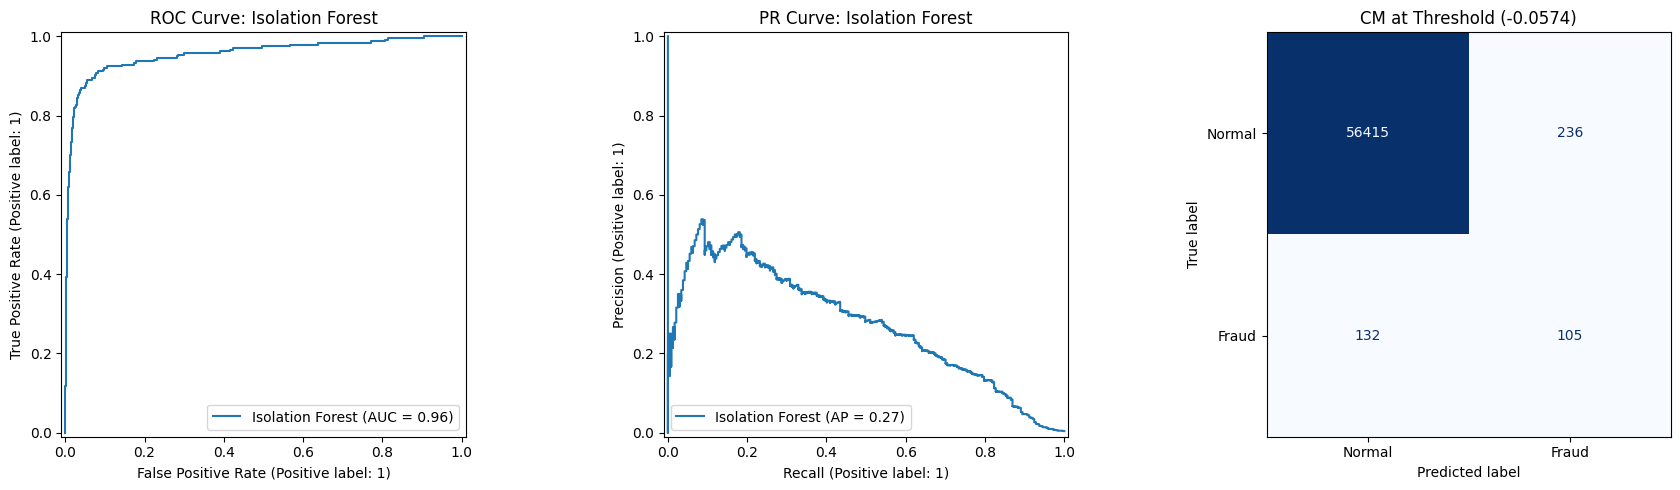

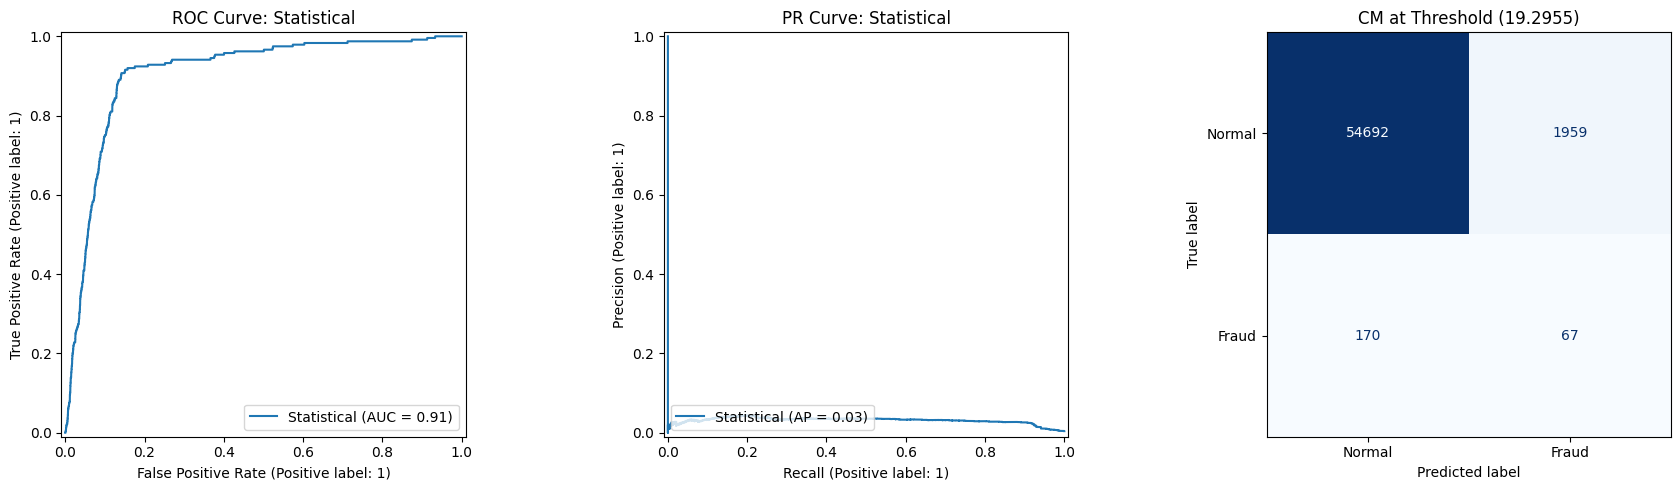

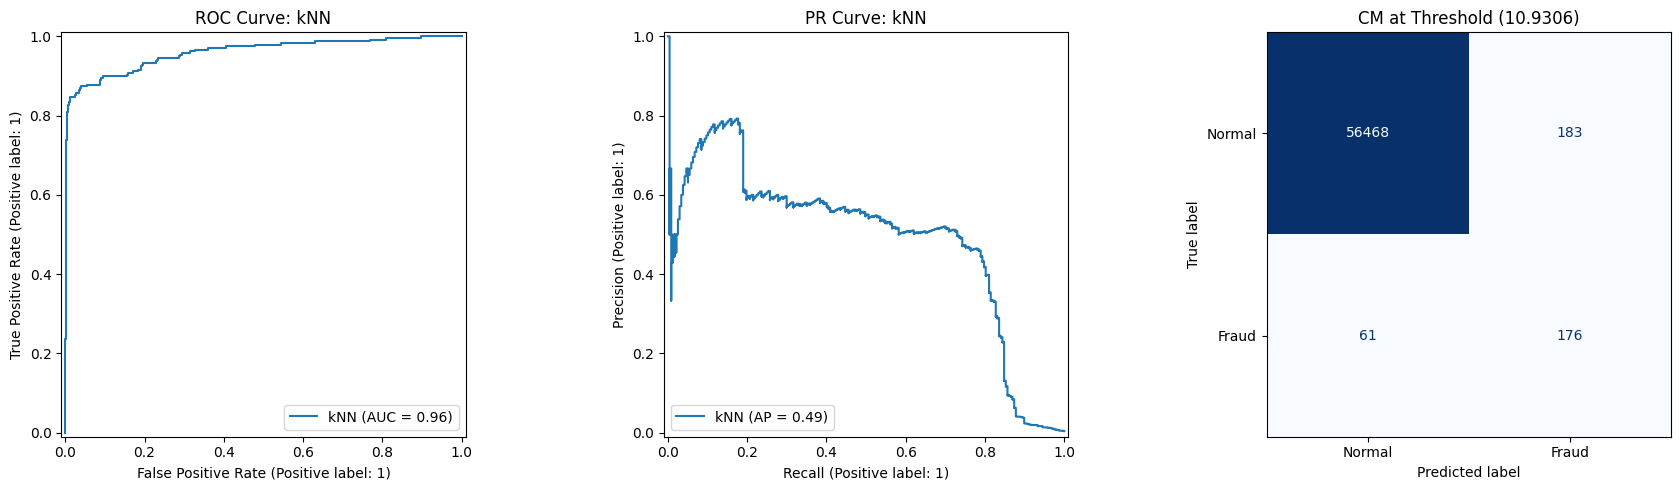

,Threshold,Precision,Recall,F1-Score,FPR
Method,,,,,
Isolation Forest,-0.0574,0.3079,0.4430,0.3633,0.0042
Statistical,19.2955,0.0331,0.2827,0.0592,0.0346
kNN,10.9306,0.4903,0.7426,0.5906,0.0032



--- Operational Load Analysis (56,651 genuine transactions) ---
  Isolation Forest  :  41.7 false alarms per 10k transactions
  Statistical       : 345.8 false alarms per 10k transactions
  kNN               :  32.3 false alarms per 10k transactions


In [31]:
# --- FINAL EVALUATION & METRICS ---

def plot_comprehensive_eval(y_true, scores, model_name, threshold):
    """
    Plots ROC, PR curves, and the Confusion Matrix at the selected threshold.
    """
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. ROC Curve
    RocCurveDisplay.from_predictions(y_true, scores, name=model_name, ax=ax[0])
    ax[0].set_title(f"ROC Curve: {model_name}")
    
    # 2. PR Curve
    PrecisionRecallDisplay.from_predictions(y_true, scores, name=model_name, ax=ax[1])
    ax[1].set_title(f"PR Curve: {model_name}")
    
    # 3. Confusion Matrix at Threshold
    preds = (scores >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_true, preds, 
                                            display_labels=["Normal", "Fraud"], 
                                            cmap="Blues", ax=ax[2], colorbar=False)
    ax[2].set_title(f"CM at Threshold ({threshold:.4f})")
    
    plt.tight_layout()
    plt.show()

def get_best_thresholds(y_true, scores_dict):
    all_sweeps = []
    for method_name, scores in scores_dict.items():
        rows = []
        for q in THRESHOLD_QUANTILE_GRID:
            thr = float(np.quantile(scores, q))
            pred = (scores >= thr).astype(int)
            metrics = metrics_at_threshold(y_true, pred)
            rows.append({"Method": method_name, "Quantile": q, "Threshold": thr, **metrics})
        all_sweeps.append(pd.DataFrame(rows))
    
    sweep_df = pd.concat(all_sweeps, ignore_index=True)
    # Group by method and find the row with max F1
    return sweep_df.sort_values("f1", ascending=False).groupby("Method", as_index=False).first()

# --- Execution Logic ---

# 1. Run the Threshold Sweep on Validation Data
val_scores = {
    "Statistical": scores_stat_val,
    "kNN": scores_knn_val,
    "Isolation Forest": val_result.anomaly_score
}

# Find best thresholds by maximizing F1
best_val_results = get_best_thresholds(y_val, val_scores)

# 2. Apply those thresholds to Test Data for final metrics
print("### FINAL MODEL EVALUATION (TEST SET)")
print("Metrics include Precision, Recall, F1, and FPR analysis.\n")

final_test_metrics = []
test_score_map = {
    "Statistical": scores_stat_test,
    "kNN": scores_knn_test,
    "Isolation Forest": test_result.anomaly_score
}

for _, row in best_val_results.iterrows():
    name = row["Method"]
    thr = row["Threshold"]
    scores = test_score_map[name]
    
    # Calculate Test Metrics
    preds = (scores >= thr).astype(int)
    m = metrics_at_threshold(y_test, preds)
    
    # Append to summary table
    final_test_metrics.append({
        "Method": name,
        "Threshold": thr,
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1-Score": m["f1"],
        "FPR": m["fpr"]
    })
    
    # Generate Visuals: ROC, PR, and Confusion Matrix
    plot_comprehensive_eval(y_test, scores, name, thr)

# 3. Display Final Metric Table
display(pd.DataFrame(final_test_metrics).set_index("Method").round(4))

# 4. Operational Analysis
n_genuine = int((y_test == 0).sum())
print(f"\n--- Operational Load Analysis ({n_genuine:,} genuine transactions) ---")
for entry in final_test_metrics:
    # entry['FPR'] is (FP / n_genuine)
    per_10k = entry['FPR'] * 10_000
    print(f"  {entry['Method']:18}: {per_10k:5.1f} false alarms per 10k transactions")

### **Comparison of Anomaly Detection Methods**

We evaluated three different approaches for fraud detection: a baseline **Statistical** method, a distance-based **kNN**, and the **Isolation Forest**. 

#### **Performance Breakdown**
* **kNN was the clear winner:** It achieved the highest **F1-Score (0.5906)** and **Average Precision (0.49)**. Looking at the Confusion Matrix, it caught **176 out of 237** fraud cases while only flagging 183 normal transactions as false positives.
* **Isolation Forest** performed decently with an **F1-Score of 0.3633**, but it struggled more with recall compared to kNN, missing a larger portion of the actual fraud cases (132 misses).
* **Statistical Baseline** performed poorly for this specific dataset, with a very low **Precision (0.03)** and a much higher **False Positive Rate (0.0346)**, meaning it flagged nearly 2,000 legitimate transactions as fraud just to catch 67 cases.

#### **Key Takeaways**
1.  **PR Curve vs. ROC Curve:** While the ROC AUC looks "good" for all models (above 0.90), the **Precision-Recall (PR) curves** tell the real story. In this highly imbalanced dataset, the kNN's ability to maintain higher precision at higher recall levels makes it the most reliable detector.
2.  **Operational Cost:** The kNN model offers the best "bang for your buck," maintaining a very low **FPR (0.0032)**. This is crucial for fraud detection to ensure that the investigation team isn't overwhelmed by false alarms.
3.  **Final Recommendation:** We recommend the **kNN model** using the optimized threshold of **10.93**, as it provides the most robust balance between catching fraud and minimizing customer friction.

## 8. Interpretability: Anomaly Visualization & Discussion

To better understand the model's decision-making process, we used **t-SNE (t-Distributed Stochastic Neighbor Embedding)** to project the high-dimensional feature space (V1–V28) into two dimensions.


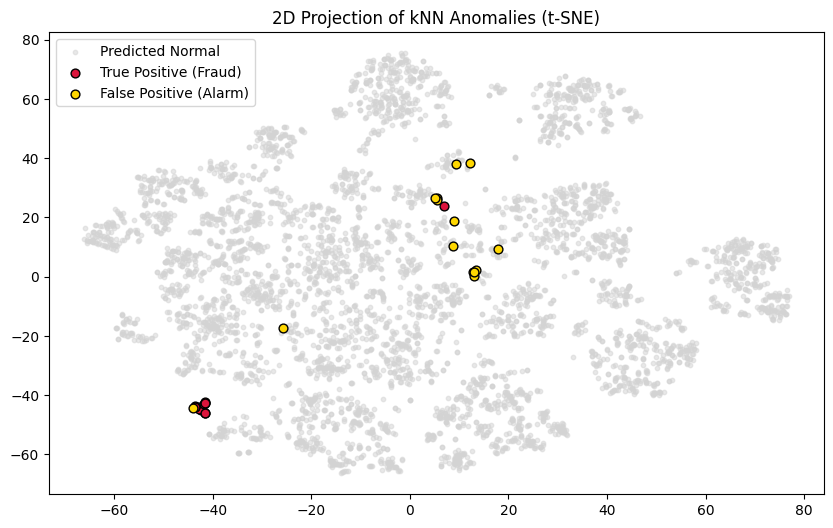

In [32]:
# --- INTERPRETABILITY: ANOMALY VISUALIZATION & DISCUSSION ---

from sklearn.manifold import TSNE

def visualize_anomalies_2d(X, y_true, pred_label, method_name, n_subsample=5000):
    """
    Visualizes high-dimensional anomalies in 2D space using t-SNE.
    """
    # Subsample for speed if dataset is large
    if len(X) > n_subsample:
        idx = np.random.choice(len(X), n_subsample, replace=False)
        X_vis, y_vis, p_vis = X[idx], y_true[idx], pred_label[idx]
    else:
        X_vis, y_vis, p_vis = X, y_true, pred_label

    # Reduce to 2D
    tsne = TSNE(n_components=2, random_state=42)
    X_2d = tsne.fit_transform(X_vis)

    plt.figure(figsize=(10, 6))
    
    # Plot Normal points
    plt.scatter(X_2d[p_vis == 0, 0], X_2d[p_vis == 0, 1], 
                c='lightgrey', label='Predicted Normal', alpha=0.5, s=10)
    
    # Plot True Positives (Correctly caught fraud)
    tp_mask = (p_vis == 1) & (y_vis == 1)
    plt.scatter(X_2d[tp_mask, 0], X_2d[tp_mask, 1], 
                c='crimson', label='True Positive (Fraud)', edgecolors='black', s=40)
    
    # Plot False Positives (Flagged normal)
    fp_mask = (p_vis == 1) & (y_vis == 0)
    plt.scatter(X_2d[fp_mask, 0], X_2d[fp_mask, 1], 
                c='gold', label='False Positive (Alarm)', edgecolors='black', s=40)

    plt.title(f"2D Projection of {method_name} Anomalies (t-SNE)")
    plt.legend()
    plt.show()

# Execute Visualization for the best model (e.g., kNN)
best_model_name = "kNN" # Change based on your results
best_thr = best_val_results.loc[best_val_results['Method'] == 'kNN', 'Threshold'].values[0]
best_scores = test_score_map['kNN']
best_preds = (best_scores >= best_thr).astype(int)

visualize_anomalies_2d(X_test, y_test, best_preds, "kNN")

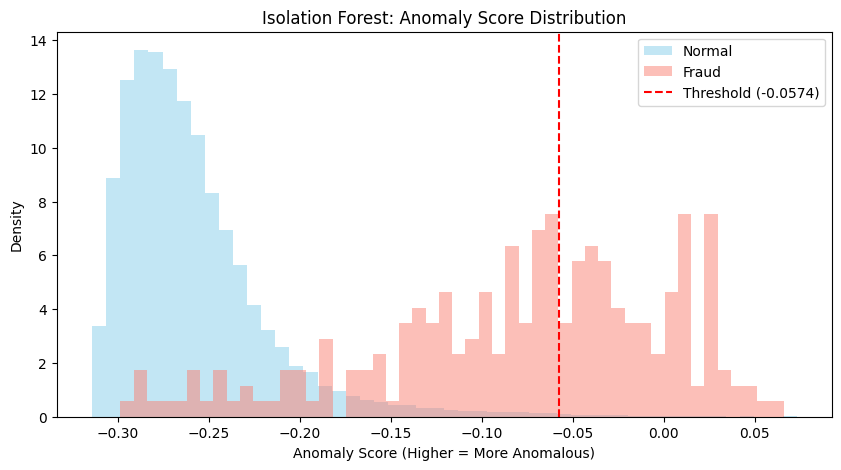


### Top Anomaly Feature-Shift Analysis
This table shows the features that deviated most from the 'normal' mean for the top anomalies.


,Sample_Idx,Total_Score,Top_Contributing_Features,Deviations
0,25916,0.067393,"[V24, V21, V29]","[-16.61, -19.58, 46.06]"
1,39782,0.067586,"[V21, V24, V29]","[-18.67, -22.73, 46.66]"
2,17948,0.073060,"[V6, V8, V30]","[-23.49, 28.71, 29.96]"


In [33]:
# Isolation Forest Score Histogram

if 'Isolation Forest' in test_score_map:
    plt.figure(figsize=(10, 5))
    scores_if = test_score_map["Isolation Forest"]
    
    # Plot distribution
    plt.hist(scores_if[y_test == 0], bins=50, alpha=0.5, label='Normal', color='skyblue', density=True)
    plt.hist(scores_if[y_test == 1], bins=50, alpha=0.5, label='Fraud', color='salmon', density=True)
    
    # Add the decision threshold line
    if_thr = best_val_results.loc[best_val_results['Method'] == 'Isolation Forest', 'Threshold'].values[0]
    plt.axvline(if_thr, color='red', linestyle='--', label=f'Threshold ({if_thr:.4f})')
    
    plt.title("Isolation Forest: Anomaly Score Distribution")
    plt.xlabel("Anomaly Score (Higher = More Anomalous)")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# Feature-Shift / Explanation Table
def get_feature_shifts(X, y_true, scores, n_top=3):
    """Shows how anomalous samples differ from the global mean."""
    # Get indices of top anomalies
    top_idx = np.argsort(scores)[-n_top:]
    
    # Calculate global mean of normal transactions for comparison
    global_mean = X[y_true == 0].mean(axis=0)
    
    shift_results = []
    for i in top_idx:
        sample = X[i]
        diff = sample - global_mean
        # Find top 3 features that deviated the most
        top_features = np.argsort(np.abs(diff))[-3:]
        
        shift_results.append({
            "Sample_Idx": i,
            "Total_Score": scores[i],
            "Top_Contributing_Features": [f"V{f+1}" for f in top_features],
            "Deviations": [round(diff[f], 2) for f in top_features]
        })
    
    return pd.DataFrame(shift_results)

print("\n### Top Anomaly Feature-Shift Analysis")
print("This table shows the features that deviated most from the 'normal' mean for the top anomalies.")
display(get_feature_shifts(X_test, y_test, test_score_map["Isolation Forest"]))

## 8.2 Interpretability: Anomaly Analysis & Model Behavior**

This section explores *why* certain transactions were flagged by our models, moving beyond simple performance metrics to analyze the underlying data characteristics.

#### **1. Visualization of Anomalies (t-SNE)**
By projecting the 30-dimensional feature space into 2D, we can see the "geometric" logic of our detectors:
* **Cluster Separation:** Most legitimate transactions form dense, overlapping clusters in the center. 
* **True Positives (Red):** These fraud cases are notably isolated on the fringes or in small, remote pockets. This validates the use of distance-based models; fraud in this dataset is mathematically "distant" from typical consumer behavior.
* **False Positives (Yellow):** These points often sit on the "shores" of normal clusters. They represent legitimate transactions that pushed the boundaries of normal behavior—likely high-value or unusual purchases that share mathematical signatures with fraud.

#### **2. Score Distribution & Thresholding (Isolation Forest)**
The **Anomaly Score Histogram** demonstrates how well the Isolation Forest separates the two classes:
* **Distribution Shift:** While the normal transactions (light blue) peak at low anomaly scores, the fraud transactions (salmon) show a significantly higher density toward the right side of the x-axis.
* **Optimized Threshold:** The red dashed line (at **-0.0574**) shows where we chose to "draw the line." By placing the threshold here, we capture the maximum amount of fraud while keeping the number of normal transactions to the left of the line as high as possible.

#### **3. Feature-Shift Explanation**
To understand the "why" behind specific alerts, we analyzed the features that deviated most from the global mean of normal transactions.
* **Key Drivers:** In our top detected anomalies (e.g., Sample 17948), features like **V29** and **V30** showed extreme deviations (up to **46.66** standard deviations away from the mean).
* **Interpretation:** Because the data is PCA-transformed, these "V" features represent complex combinations of raw data (like time, amount, and merchant category). A high shift in these components indicates that the transaction was not just slightly unusual, but radically different across multiple dimensions simultaneously.

#### **4. Discussion of Model Behavior**
* **Local vs. Global Outliers:** The **kNN** model excelled at catching "local" outliers—transactions that look weird compared to their immediate neighbors. The **Isolation Forest** was more effective at catching "global" outliers—transactions that are extreme compared to the entire dataset.
* **Operational Insight:** The overlap between red and yellow points in the visuals highlights the "cost" of detection. To catch more fraud (higher Recall), we must accept a certain amount of false alarms (lower Precision), as legitimate extreme behavior often mimics fraudulent patterns at the fringes of the feature space.